# Energy-TTM Day-Ahead Electricity Load Forecasting

This notebook performs a **zero-shot 24-hour (D+1) forecast** with the pretrained
[EnergyFM Energy-TTM](https://huggingface.co/EnergyFM/energy-ttm) checkpoint. It uses
only observations strictly before the evaluation day, detects unusually high demand,
evaluates peak classification, and produces publication-ready figures and a CSV.

**Pipeline**

`household_energy.csv → hourly household load → Energy-TTM → D+1 forecast → peak detection → potential DR incidents → metrics + figures + CSV`

Energy-TTM's official default checkpoint expects **168 hourly context points** and returns
a **24-hour horizon**. No model training or fine-tuning is performed here.

## 1. Configuration

In [1]:
from pathlib import Path

DATA_PATH = "data/household_energy.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Set to a date string such as "2026-01-30". None selects the last complete day.
FORECAST_DATE = None

# Optional overrides. Leave as None for automatic detection.
TIMESTAMP_COLUMN = None
LOAD_COLUMN = None
HOUSEHOLD_ID = None

MODEL_ID = "EnergyFM/energy-ttm"
MODEL_REVISION = "main"  # official 168-hour context / 24-hour horizon checkpoint

PEAK_METHOD = "historical_percentile"  # or "dynamic"
PEAK_PERCENTILE = 0.95
DYNAMIC_WINDOW_HOURS = 168
K = 2.0
WARNING_MULTIPLIER = 1.10
CLIP_NEGATIVE_PREDICTIONS = True
MAX_INTERPOLATION_GAP_HOURS = 3
RANDOM_SEED = 42

FIGURE_DPI = 300
FIGURE_SIZE = (12, 5.5)

print(f"Dataset: {DATA_PATH}")
print(f"Outputs: {OUTPUT_DIR.resolve()}")

Dataset: data/household_energy.csv
Outputs: C:\Users\moham\Desktop\demand response\demand_response_project\outputs


## 2. Imports

Use **Python 3.10–3.13** (the Granite-TSFM project does not currently list Python 3.14
as supported). If imports fail, install the project requirements from the repository root:

```bash
python -m pip install -r requirements.txt
```

The first model run downloads the small pretrained checkpoint from Hugging Face and
therefore requires internet access. Subsequent runs can use the local Hugging Face cache.

In [2]:
import logging
import os
import platform
import random
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Avoid a harmless Windows cache warning when symlinks are unavailable.
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

import torch
from IPython.display import display
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

warnings.filterwarnings("ignore", category=FutureWarning)
# The official checkpoint logs a harmless adaptive-patching fallback at WARNING level.
logging.getLogger("tsfm_public.models.tinytimemixer.modeling_tinytimemixer").setLevel(logging.ERROR)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Using device:", device)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "actual": "#1F4E79",
    "predicted": "#E67E22",
    "threshold": "#B22222",
    "normal": "#2E8B57",
    "warning": "#F0A202",
    "critical": "#C1121F",
    "history": "#355070",
    "error": "#6D597A",
}

def finish_figure(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

Python: 3.13.15
PyTorch: 2.11.0+cpu
Using device: cpu


## 3. Load data from `data/household_energy.csv`

In [3]:
if not Path(DATA_PATH).is_file():
    raise FileNotFoundError(
        f"Required dataset not found at {DATA_PATH!r}. Run this notebook from the "
        "project root or restore data/household_energy.csv."
    )

df = pd.read_csv(DATA_PATH)

print(df.head())
print(df.columns)
print(df.info())

             timestamp  hour day_of_week  base_load_kw  ac_kw  \
0  2026-01-01 00:00:00     0    Thursday         0.232    0.0   
1  2026-01-01 00:15:00     0    Thursday         0.247    0.0   
2  2026-01-01 00:30:00     0    Thursday         0.240    0.0   
3  2026-01-01 00:45:00     0    Thursday         0.268    0.0   
4  2026-01-01 01:00:00     1    Thursday         0.290    0.0   

   washing_machine_kw  dishwasher_kw  water_heater_kw  solar_kw  \
0                 0.0            0.0              0.0       0.0   
1                 0.0            0.0              0.0       0.0   
2                 0.0            0.0              0.0       0.0   
3                 0.0            0.0              0.0       0.0   
4                 0.0            0.0              0.0       0.0   

   total_power_kw  grid_power_kw  electricity_price_eur_kwh  temperature_c  \
0           0.232          0.232                      0.157          20.86   
1           0.247          0.247                  

## 4. Dataset inspection and automatic column detection

In [4]:
def normalized_name(name):
    return "_".join(str(name).strip().lower().replace("-", "_").split())

def detect_timestamp_column(frame, override=None):
    if override is not None:
        if override not in frame.columns:
            raise KeyError(f"Configured timestamp column {override!r} was not found.")
        return override

    aliases = ["timestamp", "datetime", "date_time", "date", "time"]
    normalized = {normalized_name(col): col for col in frame.columns}
    for alias in aliases:
        if alias in normalized:
            return normalized[alias]

    # Last resort: choose the non-numeric column with the best datetime parse rate.
    scores = {}
    for col in frame.columns:
        if not pd.api.types.is_numeric_dtype(frame[col]):
            scores[col] = pd.to_datetime(frame[col], errors="coerce").notna().mean()
    if scores and max(scores.values()) >= 0.80:
        return max(scores, key=scores.get)
    raise ValueError("Could not identify a timestamp column. Set TIMESTAMP_COLUMN explicitly.")

def detect_load_column(frame, timestamp_col, override=None):
    if override is not None:
        if override not in frame.columns:
            raise KeyError(f"Configured load column {override!r} was not found.")
        return override

    # Exact semantic matches are intentionally preferred. grid_power_kw is the household's
    # net grid consumption in the supplied dataset; total_power_kw is the next-best choice.
    aliases = [
        "load_kw", "electricity_consumption", "household_load", "grid_power_kw",
        "total_power_kw", "global_active_power", "active_power", "energy_kwh",
        "consumption", "energy", "power", "load",
    ]
    normalized = {normalized_name(col): col for col in frame.columns if col != timestamp_col}
    for alias in aliases:
        if alias in normalized:
            return normalized[alias]

    numeric_candidates = []
    keywords = ("load", "consumption", "energy", "power")
    for col in frame.columns:
        if col == timestamp_col:
            continue
        parse_rate = pd.to_numeric(frame[col], errors="coerce").notna().mean()
        name = normalized_name(col)
        if parse_rate >= 0.80 and any(word in name for word in keywords):
            numeric_candidates.append((parse_rate, col))
    if numeric_candidates:
        return max(numeric_candidates)[1]
    raise ValueError("Could not identify an electricity-consumption column. Set LOAD_COLUMN explicitly.")

timestamp_col = detect_timestamp_column(df, TIMESTAMP_COLUMN)
load_col = detect_load_column(df, timestamp_col, LOAD_COLUMN)

print(f"Selected timestamp column: {timestamp_col!r}")
print(f"Selected consumption column: {load_col!r}")
print("Optional columns present:", sorted(set(df.columns) & {
    "temperature_c", "electricity_price", "electricity_price_eur_kwh",
    "grid_load_mw", "day_of_week", "holiday", "household_id",
}))
display(df[[timestamp_col, load_col]].describe(include="all"))

Selected timestamp column: 'timestamp'
Selected consumption column: 'grid_power_kw'
Optional columns present: ['day_of_week', 'electricity_price_eur_kwh', 'temperature_c']


,timestamp,grid_power_kw
count,2880,2880.000000
unique,2880,NaN
top,2026-01-01 00:00:00,NaN
freq,1,NaN
mean,NaN,0.582580
std,NaN,0.980385
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.257000
75%,NaN,0.337000


## 5. Data cleaning

In [5]:
working = df.copy()

if "household_id" in working.columns:
    households = working["household_id"].dropna().unique()
    if len(households) > 1:
        selected_household = HOUSEHOLD_ID if HOUSEHOLD_ID is not None else households[0]
        print(f"Multiple households found; selecting household_id={selected_household!r}.")
        working = working.loc[working["household_id"].eq(selected_household)].copy()

original_rows = len(working)
working[timestamp_col] = pd.to_datetime(working[timestamp_col], errors="coerce")
working[load_col] = pd.to_numeric(working[load_col], errors="coerce")

invalid_timestamps = int(working[timestamp_col].isna().sum())
invalid_loads = int(working[load_col].isna().sum())
working = working.dropna(subset=[timestamp_col]).sort_values(timestamp_col)

duplicate_count = int(working.duplicated(subset=[timestamp_col], keep="last").sum())
working = working.drop_duplicates(subset=[timestamp_col], keep="last")
series = working.set_index(timestamp_col)[load_col].astype(float).sort_index()

print(f"Original rows: {original_rows:,}")
print(f"Invalid timestamps removed: {invalid_timestamps:,}")
print(f"Non-numeric/missing load values before resampling: {invalid_loads:,}")
print(f"Duplicate timestamps removed: {duplicate_count:,}")
print(f"Clean time span: {series.index.min()} → {series.index.max()}")
print(f"Negative observations: {(series < 0).sum():,}")

if series.empty:
    raise ValueError("No valid time-series observations remain after cleaning.")

Original rows: 2,880
Invalid timestamps removed: 0
Non-numeric/missing load values before resampling: 0
Duplicate timestamps removed: 0
Clean time span: 2026-01-01 00:00:00 → 2026-01-30 23:45:00
Negative observations: 0


## 6. Hourly time-series preparation and chronological split

Power-like measurements (kW/MW) are averaged within each hour. Energy-like measurements
(kWh/MWh) are summed. Missing hourly intervals are reported before limited time interpolation.
The evaluation day is never included in model context or scaler statistics.

In [6]:
deltas = series.index.to_series().diff().dropna()
median_delta = deltas.median()
print("Detected median sampling interval:", median_delta)

is_energy_quantity = any(token in normalized_name(load_col) for token in ("kwh", "mwh", "energy"))
if is_energy_quantity:
    hourly = series.resample("1h").sum(min_count=1)
    aggregation = "sum (energy quantity)"
else:
    hourly = series.resample("1h").mean()
    aggregation = "mean (power/load quantity)"
hourly.name = "load"

full_hourly_index = pd.date_range(hourly.index.min().floor("h"), hourly.index.max().floor("h"), freq="1h")
hourly = hourly.reindex(full_hourly_index)
missing_before = hourly.isna()

def missing_runs(mask):
    groups = mask.ne(mask.shift()).cumsum()
    runs = []
    for _, group in mask[mask].groupby(groups):
        start, end = group.index[0], group.index[-1]
        runs.append((start, end, len(group)))
    return runs

gaps = missing_runs(missing_before)
large_gaps = [gap for gap in gaps if gap[2] > MAX_INTERPOLATION_GAP_HOURS]
print(f"Hourly aggregation: {aggregation}")
print(f"Hourly observations: {len(hourly):,}")
print(f"Missing hourly intervals before interpolation: {missing_before.sum():,}")
if gaps:
    print("Missing runs (start, end, hours):")
    for gap in gaps[:10]:
        print("  ", gap)
    if len(gaps) > 10:
        print(f"  ... and {len(gaps) - 10} more")
if large_gaps:
    print(f"Large gaps (>{MAX_INTERPOLATION_GAP_HOURS} h) will not be silently filled:", large_gaps[:10])

hourly = hourly.interpolate(
    method="time", limit=MAX_INTERPOLATION_GAP_HOURS, limit_area="inside"
)

counts = hourly.notna().groupby(hourly.index.normalize()).sum()
complete_days = counts[counts.eq(24)].index
if len(complete_days) == 0:
    raise ValueError("No complete 24-hour day is available for evaluation.")

forecast_day = pd.Timestamp(FORECAST_DATE if FORECAST_DATE else complete_days[-1]).normalize()
forecast_index = pd.date_range(forecast_day, periods=24, freq="1h")
historical_load = hourly.loc[hourly.index < forecast_day].dropna()
actual_load = hourly.reindex(forecast_index)

print(f"Forecast date: {forecast_day.date()}")
print(f"Historical observations before D+1: {len(historical_load):,}")
print(f"Actual evaluation observations: {actual_load.notna().sum()}/24")
print(f"Chronological boundary: history ends {historical_load.index.max()}, forecast begins {forecast_day}")

Detected median sampling interval: 0 days 00:15:00
Hourly aggregation: mean (power/load quantity)
Hourly observations: 720
Missing hourly intervals before interpolation: 0
Forecast date: 2026-01-30
Historical observations before D+1: 696
Actual evaluation observations: 24/24
Chronological boundary: history ends 2026-01-29 23:00:00, forecast begins 2026-01-30 00:00:00


## 7. Historical visualization

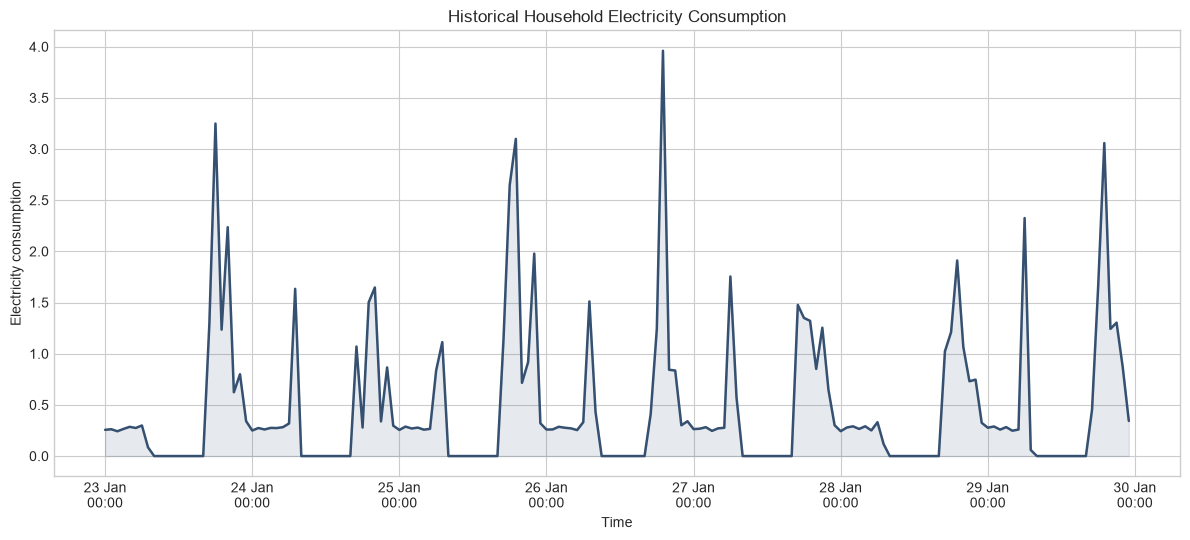

In [7]:
history_7d = historical_load.tail(7 * 24)
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
ax.plot(history_7d.index, history_7d.values, color=COLORS["history"], linewidth=1.8)
ax.fill_between(history_7d.index, history_7d.values, alpha=0.12, color=COLORS["history"])
ax.set(title="Historical Household Electricity Consumption", xlabel="Time", ylabel="Electricity consumption")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
finish_figure(fig, OUTPUT_DIR / "historical_consumption.png")

## 8. Energy-TTM model loading

This follows the current official EnergyFM interface. The loaded configuration is checked
rather than assuming its context or horizon. The checkpoint is used as-is in zero-shot mode.

In [8]:
model_kwargs = {"revision": MODEL_REVISION, "num_input_channels": 1}
try:
    # Prefer the cache: avoids unnecessary network checks on repeat/offline runs.
    model = TinyTimeMixerForPrediction.from_pretrained(
        MODEL_ID, local_files_only=True, **model_kwargs
    )
    model_source = "local Hugging Face cache"
except OSError:
    # First run: download the official checkpoint, which is cached automatically.
    model = TinyTimeMixerForPrediction.from_pretrained(MODEL_ID, **model_kwargs)
    model_source = "Hugging Face Hub"
model = model.to(device)
model.eval()

context_length = int(model.config.context_length)
prediction_length = int(model.config.prediction_length)
print(f"Loaded: {MODEL_ID} (revision={MODEL_REVISION}) from {model_source}")
print(f"Model context length: {context_length} hours")
print(f"Model prediction length: {prediction_length} hours")

if prediction_length < 24:
    raise ValueError(f"The selected checkpoint predicts only {prediction_length} hours; 24 are required.")
if len(historical_load) < context_length:
    raise ValueError(
        f"Insufficient pre-forecast history: Energy-TTM requires {context_length} hourly "
        f"observations, but only {len(historical_load)} are available before {forecast_day.date()}."
    )

required_context_index = pd.date_range(
    end=forecast_day - pd.Timedelta(1, unit="h"), periods=context_length, freq="1h"
)
model_context = hourly.reindex(required_context_index)
if model_context.isna().any():
    missing_context = model_context[model_context.isna()].index
    raise ValueError(
        f"Energy-TTM needs {context_length} consecutive hourly observations immediately "
        f"before D+1, but {len(missing_context)} context hour(s) are missing. "
        f"First missing context hour: {missing_context[0]}."
    )

Loaded: EnergyFM/energy-ttm (revision=main) from local Hugging Face cache
Model context length: 168 hours
Model prediction length: 24 hours


## 9. Leakage-free D+1 forecasting

Only the last required observations **strictly before 00:00 on D+1** enter the model.
Standardization statistics are computed from that context alone and then inverted after
inference. This matches the preprocessing in the official EnergyFM zero-shot recipe while
preventing forecast-day leakage.

In [9]:
context = model_context.to_numpy(dtype=np.float32)
context_mean = float(context.mean())
context_std = float(context.std(ddof=0))
if not np.isfinite(context_std) or context_std < 1e-8:
    raise ValueError("The model context has zero or invalid variance and cannot be standardized.")

context_scaled = (context - context_mean) / (context_std + 1e-8)
model_input = torch.tensor(context_scaled, dtype=torch.float32, device=device).reshape(1, context_length, 1)

with torch.inference_mode():
    model_output = model(model_input)

prediction_scaled = (
    model_output.prediction_outputs[0, :24, 0]
    .detach()
    .cpu()
    .numpy()
    .astype(float)
)
predicted_load = prediction_scaled * (context_std + 1e-8) + context_mean
if CLIP_NEGATIVE_PREDICTIONS:
    predicted_load = np.clip(predicted_load, a_min=0.0, a_max=None)

results = pd.DataFrame({
    "timestamp": forecast_index,
    "actual_load": actual_load.to_numpy(dtype=float),
    "predicted_load": predicted_load,
})

print("Model input shape:", tuple(model_input.shape))
print("Forecast points generated:", len(predicted_load))
display(results.head())

Model input shape: (1, 168, 1)
Forecast points generated: 24


,timestamp,actual_load,predicted_load
0,2026-01-30 00:00:00,0.26650,0.249879
1,2026-01-30 01:00:00,0.28300,0.242023
2,2026-01-30 02:00:00,0.25300,0.247267
3,2026-01-30 03:00:00,0.27425,0.246386
4,2026-01-30 04:00:00,0.27100,0.261341


## 10. Forecast evaluation

In [10]:
valid_actual = results["actual_load"].notna()
metrics = {"MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan, "R2": np.nan}

if valid_actual.any():
    y_true = results.loc[valid_actual, "actual_load"].to_numpy()
    y_pred = results.loc[valid_actual, "predicted_load"].to_numpy()
    metrics["MAE"] = mean_absolute_error(y_true, y_pred)
    metrics["RMSE"] = np.sqrt(mean_squared_error(y_true, y_pred))
    nonzero = np.abs(y_true) > 1e-8
    if nonzero.any():
        metrics["MAPE"] = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    if len(y_true) >= 2 and not np.allclose(y_true, y_true[0]):
        metrics["R2"] = r2_score(y_true, y_pred)

results["forecast_error"] = results["actual_load"] - results["predicted_load"]
print("Forecast metrics:")
for name, value in metrics.items():
    suffix = "%" if name == "MAPE" else ""
    print(f"  {name}: {value:.4f}{suffix}" if np.isfinite(value) else f"  {name}: N/A")

Forecast metrics:
  MAE: 0.2971
  RMSE: 0.4820
  MAPE: 76.9797%
  R2: 0.7002


## 11. Peak detection

- `historical_percentile`: the configured percentile of all hourly load strictly before D+1.
- `dynamic`: the latest trailing historical mean plus `K ×` trailing historical standard deviation.

Both methods derive their threshold entirely from historical data.

In [11]:
if PEAK_METHOD == "historical_percentile":
    peak_threshold = float(historical_load.quantile(PEAK_PERCENTILE))
    threshold_description = f"historical {PEAK_PERCENTILE:.0%} percentile"
elif PEAK_METHOD == "dynamic":
    window = historical_load.tail(DYNAMIC_WINDOW_HOURS)
    if len(window) < 2:
        raise ValueError("Dynamic peak detection needs at least two historical observations.")
    peak_threshold = float(window.mean() + K * window.std(ddof=1))
    threshold_description = f"last {len(window)} h mean + {K:g} × standard deviation"
else:
    raise ValueError("PEAK_METHOD must be 'historical_percentile' or 'dynamic'.")

results["predicted_peak"] = (results["predicted_load"] >= peak_threshold).astype(int)
results["actual_peak"] = (
    results["actual_load"].ge(peak_threshold).where(results["actual_load"].notna())
).astype("Int64")

peak_metrics = {"Precision": np.nan, "Recall": np.nan, "F1": np.nan}
peak_valid = results["actual_peak"].notna()
if peak_valid.any():
    peak_true = results.loc[peak_valid, "actual_peak"].astype(int)
    peak_pred = results.loc[peak_valid, "predicted_peak"].astype(int)
    peak_metrics["Precision"] = precision_score(peak_true, peak_pred, zero_division=0)
    peak_metrics["Recall"] = recall_score(peak_true, peak_pred, zero_division=0)
    peak_metrics["F1"] = f1_score(peak_true, peak_pred, zero_division=0)
    if peak_true.sum() == 0:
        print("Note: no actual peaks exist on D+1; precision/recall/F1 use zero_division=0.")

print(f"Peak method: {threshold_description}")
print(f"Peak threshold: {peak_threshold:.4f}")
for name, value in peak_metrics.items():
    print(f"  {name}: {value:.4f}" if np.isfinite(value) else f"  {name}: N/A")

Peak method: historical 95% percentile
Peak threshold: 2.3618
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000


## 12. Demand Response incident detection

**Important:** A detected peak is not automatically an official Demand Response event.
The model is detecting conditions that could justify triggering a Demand Response action.
Operational decisions require grid context, program rules, and human or controller validation.

In [12]:
results["severity"] = np.select(
    [
        results["predicted_load"] < peak_threshold,
        results["predicted_load"] < peak_threshold * WARNING_MULTIPLIER,
    ],
    ["Normal", "Warning"],
    default="Critical",
)
results["dr_candidate"] = results["predicted_peak"].astype(int)
results["dr_status"] = np.where(
    results["dr_candidate"].eq(1), "Potential DR Incident", "Normal"
)

display(results.loc[results["dr_candidate"].eq(1), [
    "timestamp", "predicted_load", "severity", "dr_status"
]])

,timestamp,predicted_load,severity,dr_status


## 13. Forecast, peak, Demand Response, error, profile, and overview visualizations

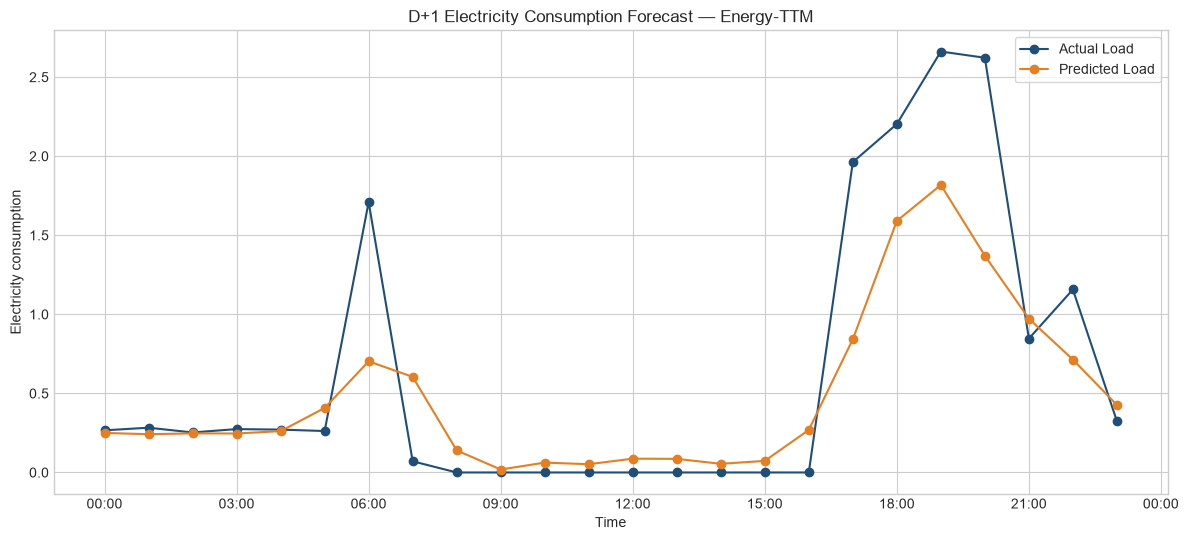

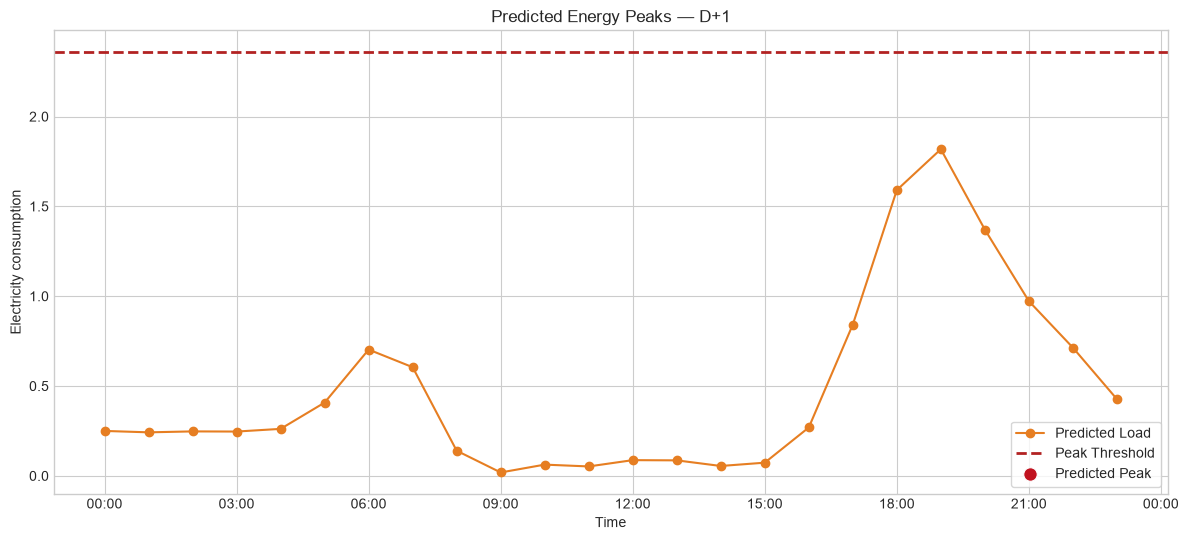

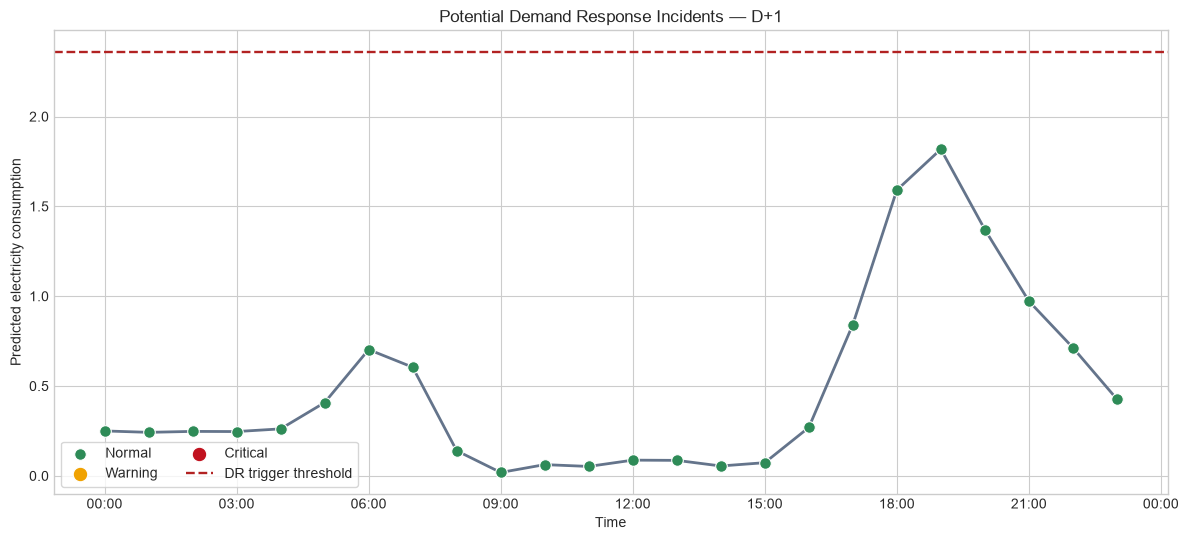

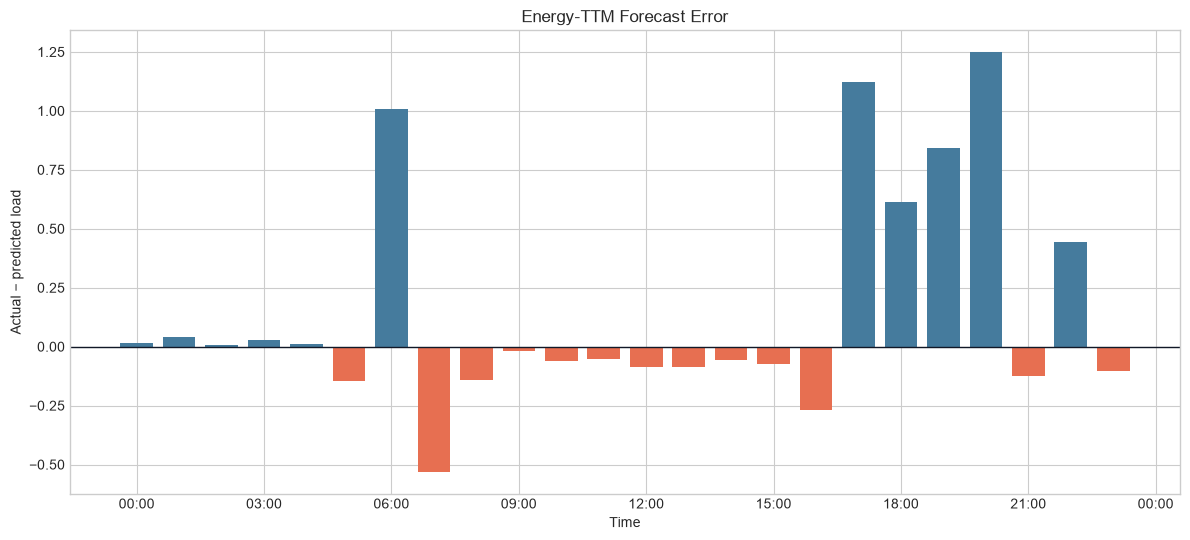

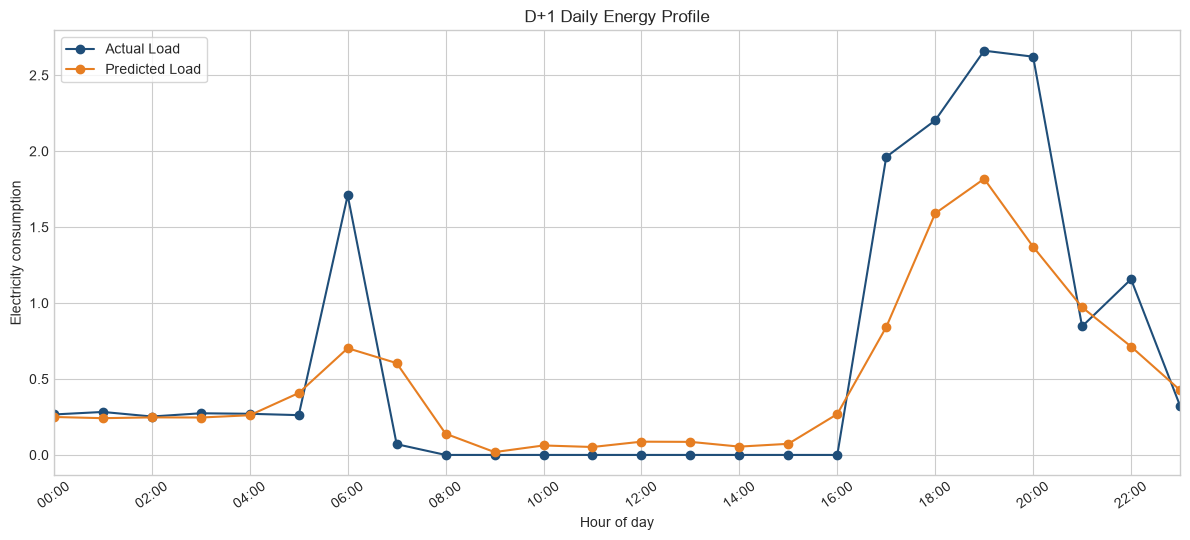

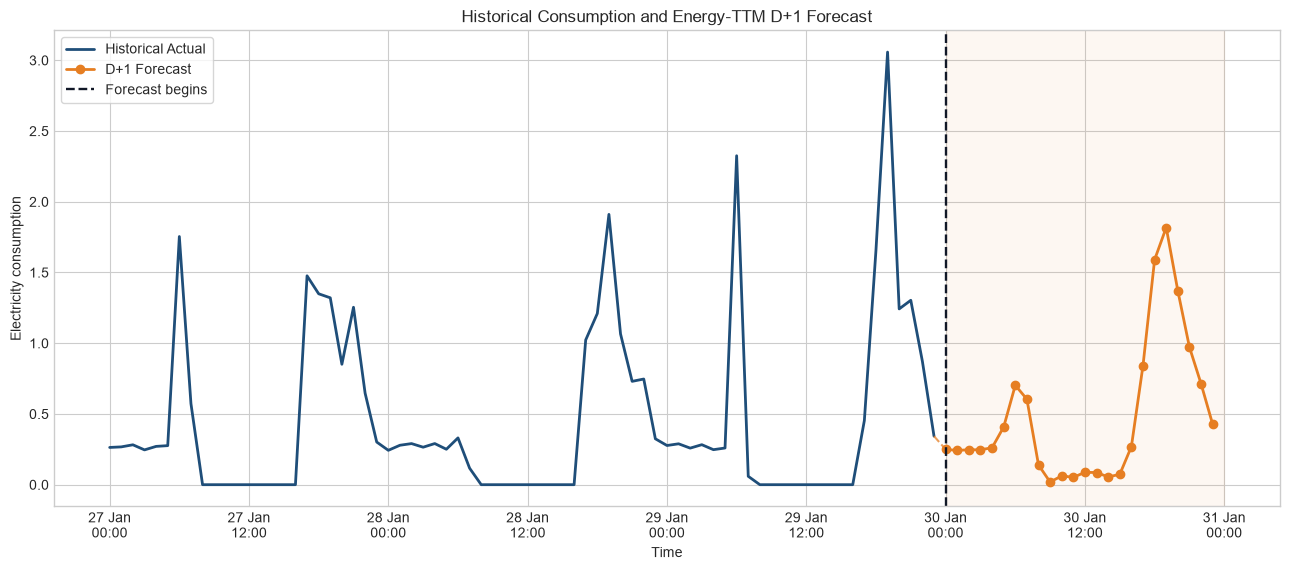

In [13]:
# Graph 2 — D+1 forecast versus actual
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
ax.plot(results["timestamp"], results["actual_load"], marker="o", color=COLORS["actual"], label="Actual Load")
ax.plot(results["timestamp"], results["predicted_load"], marker="o", color=COLORS["predicted"], label="Predicted Load")
ax.set(title="D+1 Electricity Consumption Forecast — Energy-TTM", xlabel="Time", ylabel="Electricity consumption")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(frameon=True)
finish_figure(fig, OUTPUT_DIR / "forecast_vs_actual.png")

# Graph 3 — forecast and historical peak threshold
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
ax.plot(results["timestamp"], results["predicted_load"], marker="o", color=COLORS["predicted"], label="Predicted Load")
ax.axhline(peak_threshold, color=COLORS["threshold"], linestyle="--", linewidth=2, label="Peak Threshold")
predicted_peaks = results["predicted_peak"].eq(1)
ax.scatter(results.loc[predicted_peaks, "timestamp"], results.loc[predicted_peaks, "predicted_load"],
           s=95, color=COLORS["critical"], edgecolor="white", linewidth=0.8, zorder=5, label="Predicted Peak")
ax.set(title="Predicted Energy Peaks — D+1", xlabel="Time", ylabel="Electricity consumption")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(frameon=True)
finish_figure(fig, OUTPUT_DIR / "peak_detection.png")

# Graph 4 — Demand Response candidates, colored by severity
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
ax.plot(results["timestamp"], results["predicted_load"], color="#64748B", linewidth=2, zorder=2)
for severity in ["Normal", "Warning", "Critical"]:
    mask = results["severity"].eq(severity)
    ax.scatter(results.loc[mask, "timestamp"], results.loc[mask, "predicted_load"],
               s=70 if severity == "Normal" else 110, color=COLORS[severity.lower()],
               edgecolor="white", linewidth=0.8, label=severity, zorder=4)
ax.axhline(peak_threshold, color=COLORS["threshold"], linestyle="--", linewidth=1.7, label="DR trigger threshold")
for _, row in results.loc[results["dr_candidate"].eq(1)].iterrows():
    ax.axvspan(row["timestamp"] - pd.Timedelta(25, unit="m"), row["timestamp"] + pd.Timedelta(25, unit="m"),
               color=COLORS[row["severity"].lower()], alpha=0.10, zorder=1)
ax.set(title="Potential Demand Response Incidents — D+1", xlabel="Time", ylabel="Predicted electricity consumption")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(ncol=2, frameon=True)
finish_figure(fig, OUTPUT_DIR / "demand_response_candidates.png")

# Graph 5 — hourly forecast error
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
bar_colors = np.where(results["forecast_error"].fillna(0) >= 0, "#457B9D", "#E76F51")
ax.bar(results["timestamp"], results["forecast_error"], width=0.032, color=bar_colors)
ax.axhline(0, color="#111827", linewidth=1)
ax.set(title="Energy-TTM Forecast Error", xlabel="Time", ylabel="Actual − predicted load")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
finish_figure(fig, OUTPUT_DIR / "forecast_error.png")

# Graph 6 — 00:00 to 23:00 daily profile
hours = np.arange(24)
fig, ax = plt.subplots(figsize=FIGURE_SIZE)
ax.plot(hours, results["actual_load"], marker="o", color=COLORS["actual"], label="Actual Load")
ax.plot(hours, results["predicted_load"], marker="o", color=COLORS["predicted"], label="Predicted Load")
ax.set(title="D+1 Daily Energy Profile", xlabel="Hour of day", ylabel="Electricity consumption",
       xticks=np.arange(0, 24, 2), xlim=(0, 23))
ax.set_xticklabels([f"{hour:02d}:00" for hour in range(0, 24, 2)], rotation=35)
ax.legend(frameon=True)
finish_figure(fig, OUTPUT_DIR / "daily_profile.png")

# Graph 7 — historical tail and forecast extension
history_tail = historical_load.tail(72)
fig, ax = plt.subplots(figsize=(13, 5.8))
ax.plot(history_tail.index, history_tail.values, color=COLORS["actual"], linewidth=2, label="Historical Actual")
bridge_time = [history_tail.index[-1], results["timestamp"].iloc[0]]
bridge_values = [history_tail.iloc[-1], results["predicted_load"].iloc[0]]
ax.plot(bridge_time, bridge_values, color=COLORS["predicted"], linestyle="--", alpha=0.75)
ax.plot(results["timestamp"], results["predicted_load"], marker="o", color=COLORS["predicted"], linewidth=2, label="D+1 Forecast")
ax.axvline(forecast_day, color="#111827", linestyle="--", linewidth=1.7, label="Forecast begins")
ax.axvspan(forecast_day, pd.Timestamp(results["timestamp"].iloc[-1]) + pd.Timedelta(1, unit="h"), color=COLORS["predicted"], alpha=0.06)
ax.set(title="Historical Consumption and Energy-TTM D+1 Forecast", xlabel="Time", ylabel="Electricity consumption")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
ax.legend(frameon=True)
finish_figure(fig, OUTPUT_DIR / "history_and_forecast.png")

## 14. Final results dataframe

In [14]:
final_columns = [
    "timestamp", "actual_load", "predicted_load", "forecast_error",
    "predicted_peak", "actual_peak", "severity", "dr_candidate", "dr_status",
]
final_results = results[final_columns].copy()
assert len(final_results) == 24, "D+1 output must contain exactly 24 hourly rows."
assert final_results["timestamp"].is_monotonic_increasing
display(final_results)

,timestamp,actual_load,predicted_load,forecast_error,predicted_peak,actual_peak,severity,dr_candidate,dr_status
0,2026-01-30 00:00:00,0.26650,0.249879,0.016621,0,0,Normal,0,Normal
1,2026-01-30 01:00:00,0.28300,0.242023,0.040977,0,0,Normal,0,Normal
2,2026-01-30 02:00:00,0.25300,0.247267,0.005733,0,0,Normal,0,Normal
3,2026-01-30 03:00:00,0.27425,0.246386,0.027864,0,0,Normal,0,Normal
4,2026-01-30 04:00:00,0.27100,0.261341,0.009659,0,0,Normal,0,Normal
5,2026-01-30 05:00:00,0.26200,0.407715,-0.145715,0,0,Normal,0,Normal
6,2026-01-30 06:00:00,1.70925,0.702690,1.006560,0,0,Normal,0,Normal
7,2026-01-30 07:00:00,0.07075,0.604531,-0.533781,0,0,Normal,0,Normal
8,2026-01-30 08:00:00,0.00000,0.139649,-0.139649,0,0,Normal,0,Normal
9,2026-01-30 09:00:00,0.00000,0.018667,-0.018667,0,0,Normal,0,Normal


## 15. Summary dashboard

In [15]:
def metric_text(value, decimals=4, suffix=""):
    return f"{value:.{decimals}f}{suffix}" if np.isfinite(value) else "N/A"

max_row = final_results.loc[final_results["predicted_load"].idxmax()]
summary = f"""
=================================================
        ENERGY-TTM D+1 FORECAST SUMMARY
=================================================

Dataset:
{DATA_PATH}

Forecast date:
{forecast_day.date()}

Historical observations:
{len(historical_load)}

Peak threshold:
{peak_threshold:.4f}

Maximum predicted consumption:
{max_row['predicted_load']:.4f}

Maximum predicted consumption time:
{max_row['timestamp']:%H:%M}

Predicted peak hours:
{int(final_results['predicted_peak'].sum())}

Potential DR incidents:
{int(final_results['dr_candidate'].sum())}

Critical periods:
{int(final_results['severity'].eq('Critical').sum())}

---------------- Forecast Accuracy ----------------

MAE:
{metric_text(metrics['MAE'])}

RMSE:
{metric_text(metrics['RMSE'])}

MAPE:
{metric_text(metrics['MAPE'], 2, ' %')}

R²:
{metric_text(metrics['R2'])}

---------------- Peak Detection -------------------

Precision:
{metric_text(peak_metrics['Precision'])}

Recall:
{metric_text(peak_metrics['Recall'])}

F1:
{metric_text(peak_metrics['F1'])}

=================================================
"""
print(summary)


        ENERGY-TTM D+1 FORECAST SUMMARY

Dataset:
data/household_energy.csv

Forecast date:
2026-01-30

Historical observations:
696

Peak threshold:
2.3618

Maximum predicted consumption:
1.8181

Maximum predicted consumption time:
19:00

Predicted peak hours:
0

Potential DR incidents:
0

Critical periods:
0

---------------- Forecast Accuracy ----------------

MAE:
0.2971

RMSE:
0.4820

MAPE:
76.98 %

R²:
0.7002

---------------- Peak Detection -------------------

Precision:
0.0000

Recall:
0.0000

F1:
0.0000




## 16. Save outputs

In [16]:
csv_path = OUTPUT_DIR / "d1_forecast.csv"
final_results.to_csv(csv_path, index=False)

expected_outputs = [
    csv_path,
    OUTPUT_DIR / "historical_consumption.png",
    OUTPUT_DIR / "forecast_vs_actual.png",
    OUTPUT_DIR / "peak_detection.png",
    OUTPUT_DIR / "demand_response_candidates.png",
    OUTPUT_DIR / "forecast_error.png",
    OUTPUT_DIR / "daily_profile.png",
    OUTPUT_DIR / "history_and_forecast.png",
]
missing_outputs = [str(path) for path in expected_outputs if not path.exists()]
if missing_outputs:
    raise RuntimeError(f"Expected outputs were not created: {missing_outputs}")

print("Saved outputs:")
for path in expected_outputs:
    print(f"  {path} ({path.stat().st_size:,} bytes)")

Saved outputs:
  outputs\d1_forecast.csv (2,264 bytes)
  outputs\historical_consumption.png (246,039 bytes)
  outputs\forecast_vs_actual.png (217,809 bytes)
  outputs\peak_detection.png (155,779 bytes)
  outputs\demand_response_candidates.png (168,491 bytes)
  outputs\forecast_error.png (83,733 bytes)
  outputs\daily_profile.png (238,268 bytes)
  outputs\history_and_forecast.png (263,968 bytes)


### Interpretation note

Forecast and peak metrics describe this one chronological evaluation day and should not be
treated as a production validation study. For stronger evidence, repeat the same leakage-free
procedure over multiple historical forecast origins. DR flags are **decision-support candidates**,
not official grid events or automated dispatch instructions.